## Minirocket new

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
candidate_paths = [
    Path("../dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("CMI_timeseries_preprocessed_outputs.pkl"),
]

preprocessed_path = None

for path in candidate_paths:
    if path.exists():
        preprocessed_path = path
        break

if preprocessed_path is None:
    raise FileNotFoundError(
        "CMI_timeseries_preprocessed_outputs.pkl not found. "
        "Check the relative path from the current notebook."
    )

with open(preprocessed_path, "rb") as f:
    preprocessing_output = pickle.load(f)

print("Loaded:", preprocessed_path)
print("\nAvailable keys:")
for key in preprocessing_output.keys():
    print("-", key)

Loaded: ../dataset/CMI_timeseries_preprocessed_outputs.pkl

Available keys:
- CMI_timeseries_preprocessed
- CMI_timeseries_global_scaled
- CMI_timeseries_subject_scaled
- signal_cols
- id_col
- target_col
- target_df
- filtered_target_df
- non_wear_df
- hampel_summary_df


In [3]:
selected_source_name = "CMI_timeseries_global_scaled"

if selected_source_name not in preprocessing_output:
    raise KeyError(
        f"{selected_source_name} not found in preprocessing_output. "
        f"Available keys are: {list(preprocessing_output.keys())}"
    )

ts_source = preprocessing_output[selected_source_name]

print("Selected source:", selected_source_name)
print("Type:", type(ts_source))
print("Length:", len(ts_source))
print("Shape:", getattr(ts_source, "shape", None))

Selected source: CMI_timeseries_global_scaled
Type: <class 'list'>
Length: 4310
Shape: None


In [4]:
metadata_candidates = [
    "filtered_target_df",
    "metadata_df",
    "CMI_timeseries_metadata_filtered",
]

metadata_df = None
used_metadata_key = None

for key in metadata_candidates:
    if key in preprocessing_output:
        metadata_df = preprocessing_output[key].copy()
        used_metadata_key = key
        break

if metadata_df is None:
    raise KeyError(
        "No aligned metadata dataframe found in preprocessing_output. "
        f"Available keys are: {list(preprocessing_output.keys())}"
    )

print("Using metadata key:", used_metadata_key)
print("metadata_df shape:", metadata_df.shape)
print("metadata_df columns:", metadata_df.columns.tolist())

if len(metadata_df) != len(ts_source):
    raise ValueError(
        f"Length mismatch: ts_source has {len(ts_source)} windows, "
        f"metadata_df has {len(metadata_df)} rows."
    )

Using metadata key: filtered_target_df
metadata_df shape: (4310, 3)
metadata_df columns: ['filtered_series_index', 'subject_id', 'target_value']


In [5]:
candidate_subject_cols = [
    "subject_id",
    "id",
    "participant_id",
    "PCIAT_id"
]

candidate_target_cols = [
    "target",
    "target_value",
    "sii_binary",
    "sii",
    "label",
    "class"
]

subject_col = None
for col in candidate_subject_cols:
    if col in metadata_df.columns:
        subject_col = col
        break

target_col = None
for col in candidate_target_cols:
    if col in metadata_df.columns:
        target_col = col
        break

if subject_col is None:
    raise KeyError(
        f"No subject column found. Available columns are: {metadata_df.columns.tolist()}"
    )

if target_col is None:
    raise KeyError(
        f"No target column found. Available columns are: {metadata_df.columns.tolist()}"
    )

print("Using subject column:", subject_col)
print("Using target column:", target_col)

print("\nTarget distribution:")
print(metadata_df[target_col].value_counts(dropna=False).sort_index())

print("\nNumber of unique subjects:", metadata_df[subject_col].nunique())

Using subject column: subject_id
Using target column: target_value

Target distribution:
target_value
0    2888
1    1422
Name: count, dtype: int64

Number of unique subjects: 375


In [6]:
if "signal_cols" in preprocessing_output:
    signal_cols = preprocessing_output["signal_cols"]
else:
    signal_cols = ["X", "Y", "Z", "enmo", "anglez", "light"]

print("Signal columns:", signal_cols)

if isinstance(ts_source, list):
    X_list = []

    for i, ts_df in enumerate(ts_source):
        missing_cols = [col for col in signal_cols if col not in ts_df.columns]
        if missing_cols:
            raise KeyError(f"Window {i} is missing columns: {missing_cols}")

        X_list.append(ts_df[signal_cols].to_numpy(dtype=float))

    X_ts = np.stack(X_list, axis=0)

else:
    X_ts = np.asarray(ts_source, dtype=float)

if X_ts.ndim != 3:
    raise ValueError(f"Expected a 3D time-series array, got shape {X_ts.shape}")

print("Original X_ts shape:", X_ts.shape)

# Expected internal format before MiniRocket: (n_windows, n_timepoints, n_channels)
if X_ts.shape[1] == len(signal_cols) and X_ts.shape[2] != len(signal_cols):
    # It is probably already (n_windows, n_channels, n_timepoints)
    X_ts_time_channel = np.transpose(X_ts, (0, 2, 1))
else:
    X_ts_time_channel = X_ts

print("Time-channel format:", X_ts_time_channel.shape)

# MiniRocketMultivariate expects: (n_instances, n_channels, n_timepoints)
X_minirocket = np.transpose(X_ts_time_channel, (0, 2, 1))

print("MiniRocket input shape:", X_minirocket.shape)
print("Expected: (n_windows, n_channels, n_timepoints)")

Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
Original X_ts shape: (4310, 200, 6)
Time-channel format: (4310, 200, 6)
MiniRocket input shape: (4310, 6, 200)
Expected: (n_windows, n_channels, n_timepoints)


In [7]:
y = metadata_df[target_col].copy()
groups = metadata_df[subject_col].copy()

# Remove missing target rows, if any
valid_mask = y.notna() & groups.notna()

X_minirocket = X_minirocket[valid_mask.values]
y = y.loc[valid_mask].astype(int).reset_index(drop=True)
groups = groups.loc[valid_mask].reset_index(drop=True)

print("X_minirocket shape after filtering:", X_minirocket.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nUnique subjects:", groups.nunique())

X_minirocket shape after filtering: (4310, 6, 200)
y shape: (4310,)
groups shape: (4310,)

Target distribution:
target_value
0    2888
1    1422
Name: count, dtype: int64

Unique subjects: 375


In [8]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_minirocket, y, groups=groups))

X_train = X_minirocket[train_idx]
X_test = X_minirocket[test_idx]

y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

groups_train = groups.iloc[train_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nUnique train subjects:", groups_train.nunique())
print("Unique test subjects:", groups_test.nunique())

overlap_subjects = set(groups_train).intersection(set(groups_test))

print("\nNumber of overlapping subjects:", len(overlap_subjects))

if len(overlap_subjects) > 0:
    raise ValueError("DATA LEAKAGE: some subjects appear in both train and test.")
else:
    print("No subject leakage detected.")

X_train: (2897, 6, 200)
X_test: (1413, 6, 200)

Train target distribution:
target_value
0    0.655506
1    0.344494
Name: proportion, dtype: float64

Test target distribution:
target_value
0    0.699929
1    0.300071
Name: proportion, dtype: float64

Unique train subjects: 262
Unique test subjects: 113

Number of overlapping subjects: 0
No subject leakage detected.


In [10]:
# Import MiniRocket multivariate transformer

try:
    from sktime.transformations.panel.rocket import MiniRocketMultivariate
    print("Imported MiniRocketMultivariate from sktime.transformations.panel.rocket")

except ImportError:
    try:
        from sktime.transformations.panel.rocket import MiniRocketMultivariateVariable as MiniRocketMultivariate
        print("Imported MiniRocketMultivariateVariable as MiniRocketMultivariate")

    except ImportError as e:
        raise ImportError(
            "Could not import MiniRocketMultivariate. "
            "Install or update sktime with: pip install -U sktime"
        ) from e

Imported MiniRocketMultivariate from sktime.transformations.panel.rocket


In [11]:
minirocket = MiniRocketMultivariate(
    num_kernels=10000,
    random_state=42
)

print("Fitting MiniRocket on training set only...")
minirocket.fit(X_train)

print("Transforming train...")
X_train_mr = minirocket.transform(X_train)

print("Transforming test...")
X_test_mr = minirocket.transform(X_test)

# Convert to numpy arrays, in case sktime returns a dataframe
X_train_mr = np.asarray(X_train_mr)
X_test_mr = np.asarray(X_test_mr)

print("X_train_mr shape:", X_train_mr.shape)
print("X_test_mr shape:", X_test_mr.shape)

Fitting MiniRocket on training set only...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Transforming train...
Transforming test...
X_train_mr shape: (2897, 9996)
X_test_mr shape: (1413, 9996)


In [12]:
def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "model": model_name,

        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_balanced_accuracy": balanced_accuracy_score(y_train, y_train_pred),
        "train_f1_macro": f1_score(y_train, y_train_pred, average="macro", zero_division=0),

        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    print("\nMain metrics:")
    for key, value in results.items():
        if key != "model":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_test_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion matrix - {model_name}")
    plt.grid(False)
    plt.show()

    return results

In [13]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(
    X_train_mr,
    y_train,
    groups=groups_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ....................................logreg__C=0.001; total time= 1.2min
[CV] END ....................................logreg__C=0.001; total time= 1.3min
[CV] END ....................................logreg__C=0.001; total time= 1.4min
[CV] END ....................................logreg__C=0.001; total time= 1.5min
[CV] END ....................................logreg__C=0.001; total time= 1.7min
[CV] END .....................................logreg__C=0.01; total time= 5.2min
[CV] END .....................................logreg__C=0.01; total time= 5.7min
[CV] END .....................................logreg__C=0.01; total time= 6.1min
[CV] END .....................................logreg__C=0.01; total time= 7.7min
[CV] END .....................................logreg__C=0.01; total time= 6.6min
[CV] END ......................................logreg__C=0.1; total time=11.7min
[CV] END ......................................lo

Exception ignored in: <function ResourceTracker.__del__ at 0x10304dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END .....................................logreg__C=10.0; total time=12.5min
[CV] END .....................................logreg__C=10.0; total time= 9.5min


Exception ignored in: <function ResourceTracker.__del__ at 0x105839bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108839bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END .....................................logreg__C=10.0; total time=12.3min


Exception ignored in: <function ResourceTracker.__del__ at 0x106ed5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END .....................................logreg__C=10.0; total time=15.8min


Exception ignored in: <function ResourceTracker.__del__ at 0x110ed1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105299bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Best parameters:
{'logreg__C': 0.001}

Best CV balanced accuracy:
0.6001957247696824


MiniRocket full global-scaled + tuned Logistic Regression

Main metrics:
train_accuracy: 0.9027
train_balanced_accuracy: 0.9091
train_f1_macro: 0.8955
test_accuracy: 0.5775
test_balanced_accuracy: 0.5466
test_f1_macro: 0.5370
test_precision_macro: 0.5406
test_recall_macro: 0.5466

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.62      0.67       989
           1       0.35      0.47      0.40       424

    accuracy                           0.58      1413
   macro avg       0.54      0.55      0.54      1413
weighted avg       0.62      0.58      0.59      1413



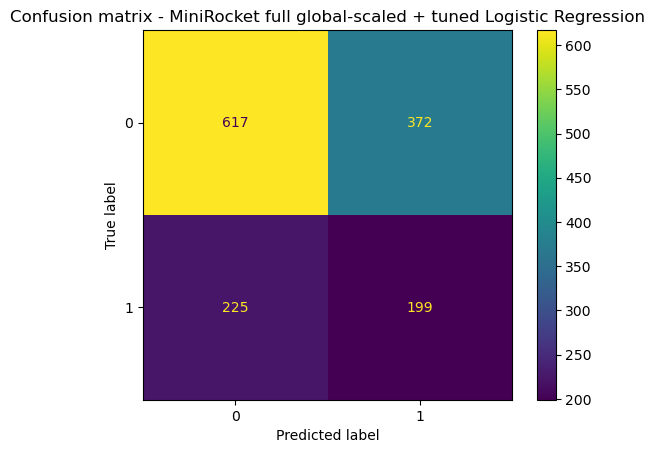

Exception ignored in: <function ResourceTracker.__del__ at 0x106f39bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104a25bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [14]:
best_lr = grid_search.best_estimator_

tuned_results = evaluate_classifier(
    best_lr,
    X_train_mr,
    y_train,
    X_test_mr,
    y_test,
    model_name="MiniRocket full global-scaled + tuned Logistic Regression"
)

## MINIROCKET on PAA

In [15]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd

# Load approximation outputs
candidate_paths = [
    Path("../dataset/CMI_timeseries_approximation_outputs.pkl"),
    Path("dataset/CMI_timeseries_approximation_outputs.pkl"),
    Path("CMI_timeseries_approximation_outputs.pkl"),
]

approx_path = None

for path in candidate_paths:
    if path.exists():
        approx_path = path
        break

if approx_path is None:
    raise FileNotFoundError(
        "CMI_timeseries_approximation_outputs.pkl not found. "
        "Check the relative path from the current notebook."
    )

with open(approx_path, "rb") as f:
    approximation_outputs = pickle.load(f)

print("Loaded:", approx_path)
print("Available keys:")
for key in approximation_outputs.keys():
    print("-", key)

Loaded: ../dataset/CMI_timeseries_approximation_outputs.pkl
Available keys:
- X_paa_global
- X_paa_subject
- sax_df
- signal_cols
- id_col
- target_col
- n_segments
- alphabet_size
- signal_to_sax


In [16]:
# Select PAA representation used for classification

selected_paa_name = "X_paa_subject"

if selected_paa_name not in approximation_outputs:
    raise KeyError(
        f"{selected_paa_name} not found. "
        f"Available keys are: {list(approximation_outputs.keys())}"
    )

X_paa = approximation_outputs[selected_paa_name]

X_paa = np.asarray(X_paa, dtype=float)

print("Selected PAA dataset:", selected_paa_name)
print("X_paa shape:", X_paa.shape)

Selected PAA dataset: X_paa_subject
X_paa shape: (4310, 50, 6)


In [17]:
# Load preprocessing outputs to get aligned metadata

candidate_paths = [
    Path("../dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("CMI_timeseries_preprocessed_outputs.pkl"),
]

preprocessed_path = None

for path in candidate_paths:
    if path.exists():
        preprocessed_path = path
        break

if preprocessed_path is None:
    raise FileNotFoundError(
        "CMI_timeseries_preprocessed_outputs.pkl not found. "
        "Check the relative path from the current notebook."
    )

with open(preprocessed_path, "rb") as f:
    preprocessing_output = pickle.load(f)

metadata_candidates = [
    "filtered_target_df",
    "metadata_df",
    "CMI_timeseries_metadata_filtered",
]

metadata_df = None

for key in metadata_candidates:
    if key in preprocessing_output:
        metadata_df = preprocessing_output[key].copy()
        print("Using metadata key:", key)
        break

if metadata_df is None:
    raise KeyError(
        f"No aligned metadata found. Available keys are: {list(preprocessing_output.keys())}"
    )

print("metadata_df shape:", metadata_df.shape)
print("metadata_df columns:", metadata_df.columns.tolist())

if len(metadata_df) != len(X_paa):
    raise ValueError(
        f"Length mismatch: X_paa has {len(X_paa)} windows, "
        f"metadata_df has {len(metadata_df)} rows."
    )

Using metadata key: filtered_target_df
metadata_df shape: (4310, 3)
metadata_df columns: ['filtered_series_index', 'subject_id', 'target_value']


In [18]:
# Prepare PAA input for MiniRocketMultivariate

if "signal_cols" in preprocessing_output:
    signal_cols = preprocessing_output["signal_cols"]
else:
    signal_cols = ["X", "Y", "Z", "enmo", "anglez", "light"]

print("Signal columns:", signal_cols)

if X_paa.ndim != 3:
    raise ValueError(f"Expected a 3D PAA array, got shape {X_paa.shape}")

print("Original X_paa shape:", X_paa.shape)

# Expected original format: (n_windows, n_segments, n_channels)
# MiniRocket format: (n_windows, n_channels, n_segments)
if X_paa.shape[2] == len(signal_cols):
    X_minirocket_paa = np.transpose(X_paa, (0, 2, 1))
elif X_paa.shape[1] == len(signal_cols):
    X_minirocket_paa = X_paa
else:
    raise ValueError(
        f"Cannot infer PAA orientation from shape {X_paa.shape} "
        f"and {len(signal_cols)} signal columns."
    )

print("MiniRocket PAA input shape:", X_minirocket_paa.shape)
print("Expected: (n_windows, n_channels, n_paa_segments)")

Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
Original X_paa shape: (4310, 50, 6)
MiniRocket PAA input shape: (4310, 6, 50)
Expected: (n_windows, n_channels, n_paa_segments)


In [19]:
# Detect subject and target columns

candidate_subject_cols = ["subject_id", "id", "participant_id", "PCIAT_id"]
candidate_target_cols = ["target", "target_value", "sii_binary", "sii", "label", "class"]

subject_col = None
for col in candidate_subject_cols:
    if col in metadata_df.columns:
        subject_col = col
        break

target_col = None
for col in candidate_target_cols:
    if col in metadata_df.columns:
        target_col = col
        break

if subject_col is None:
    raise KeyError(f"No subject column found. Available columns: {metadata_df.columns.tolist()}")

if target_col is None:
    raise KeyError(f"No target column found. Available columns: {metadata_df.columns.tolist()}")

print("Using subject column:", subject_col)
print("Using target column:", target_col)

y = metadata_df[target_col].copy()
groups = metadata_df[subject_col].copy()

valid_mask = y.notna() & groups.notna()

X_minirocket_paa = X_minirocket_paa[valid_mask.values]
y = y.loc[valid_mask].astype(int).reset_index(drop=True)
groups = groups.loc[valid_mask].reset_index(drop=True)

print("X_minirocket_paa shape:", X_minirocket_paa.shape)
print("y distribution:")
print(y.value_counts(normalize=True).sort_index())
print("Unique subjects:", groups.nunique())

Using subject column: subject_id
Using target column: target_value
X_minirocket_paa shape: (4310, 6, 50)
y distribution:
target_value
0    0.67007
1    0.32993
Name: proportion, dtype: float64
Unique subjects: 375


In [20]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_minirocket_paa, y, groups=groups))

X_train = X_minirocket_paa[train_idx]
X_test = X_minirocket_paa[test_idx]

y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

groups_train = groups.iloc[train_idx].reset_index(drop=True)
groups_test = groups.iloc[test_idx].reset_index(drop=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

print("\nUnique train subjects:", groups_train.nunique())
print("Unique test subjects:", groups_test.nunique())

overlap_subjects = set(groups_train).intersection(set(groups_test))
print("\nOverlapping subjects:", len(overlap_subjects))

if len(overlap_subjects) > 0:
    raise ValueError("DATA LEAKAGE: some subjects appear in both train and test.")
else:
    print("No subject leakage detected.")

X_train: (2897, 6, 50)
X_test: (1413, 6, 50)

Train target distribution:
target_value
0    0.655506
1    0.344494
Name: proportion, dtype: float64

Test target distribution:
target_value
0    0.699929
1    0.300071
Name: proportion, dtype: float64

Unique train subjects: 262
Unique test subjects: 113

Overlapping subjects: 0
No subject leakage detected.


In [21]:
try:
    from sktime.transformations.panel.rocket import MiniRocketMultivariate
    print("Imported MiniRocketMultivariate.")
except ImportError:
    try:
        from sktime.transformations.panel.rocket import MiniRocketMultivariateVariable as MiniRocketMultivariate
        print("Imported MiniRocketMultivariateVariable as MiniRocketMultivariate.")
    except ImportError as e:
        raise ImportError(
            "Could not import MiniRocketMultivariate. "
            "Run: pip install -U sktime"
        ) from e

Imported MiniRocketMultivariate.


In [22]:
minirocket_paa = MiniRocketMultivariate(
    num_kernels=10000,
    random_state=42
)

print("Fitting MiniRocket on PAA training set only...")
minirocket_paa.fit(X_train)

print("Transforming PAA train...")
X_train_mr_paa = minirocket_paa.transform(X_train)

print("Transforming PAA test...")
X_test_mr_paa = minirocket_paa.transform(X_test)

X_train_mr_paa = np.asarray(X_train_mr_paa)
X_test_mr_paa = np.asarray(X_test_mr_paa)

print("X_train_mr_paa shape:", X_train_mr_paa.shape)
print("X_test_mr_paa shape:", X_test_mr_paa.shape)

Fitting MiniRocket on PAA training set only...
Transforming PAA train...
Transforming PAA test...
X_train_mr_paa shape: (2897, 9996)
X_test_mr_paa shape: (1413, 9996)


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

def evaluate_classifier(model, X_train, y_train, X_test, y_test, model_name="Model"):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "train_balanced_accuracy": balanced_accuracy_score(y_train, y_train_pred),
        "train_f1_macro": f1_score(y_train, y_train_pred, average="macro", zero_division=0),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "test_f1_macro": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_precision_macro": precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_test_pred, average="macro", zero_division=0),
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    for key, value in results.items():
        if key != "model":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion matrix - {model_name}")
    plt.grid(False)
    plt.show()

    return results

In [24]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_paa_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="saga",
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_search_paa = GridSearchCV(
    estimator=lr_paa_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search_paa.fit(
    X_train_mr_paa,
    y_train,
    groups=groups_train
)

print("Best parameters:")
print(grid_search_paa.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_search_paa.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ....................................logreg__C=0.001; total time=  40.2s
[CV] END ....................................logreg__C=0.001; total time=  44.8s
[CV] END ....................................logreg__C=0.001; total time=  45.8s
[CV] END ....................................logreg__C=0.001; total time=  46.1s
[CV] END ....................................logreg__C=0.001; total time=  48.0s
[CV] END .....................................logreg__C=0.01; total time= 2.0min
[CV] END .....................................logreg__C=0.01; total time= 2.3min
[CV] END .....................................logreg__C=0.01; total time= 2.4min
[CV] END .....................................logreg__C=0.01; total time= 2.1min
[CV] END .....................................logreg__C=0.01; total time= 2.1min
[CV] END ......................................logreg__C=0.1; total time= 4.4min
[CV] END ......................................lo

Exception ignored in: <function ResourceTracker.__del__ at 0x1026c9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END .....................................logreg__C=10.0; total time= 9.0min
Best parameters:
{'logreg__C': 0.001}

Best CV balanced accuracy:
0.5754469360588781


MiniRocket on PAA + tuned Logistic Regression
train_accuracy: 0.9313
train_balanced_accuracy: 0.9386
train_f1_macro: 0.9260
test_accuracy: 0.5747
test_balanced_accuracy: 0.5372
test_f1_macro: 0.5299
test_precision_macro: 0.5328
test_recall_macro: 0.5372

Classification report:
              precision    recall  f1-score   support

           0       0.73      0.63      0.67       989
           1       0.34      0.44      0.38       424

    accuracy                           0.57      1413
   macro avg       0.53      0.54      0.53      1413
weighted avg       0.61      0.57      0.59      1413



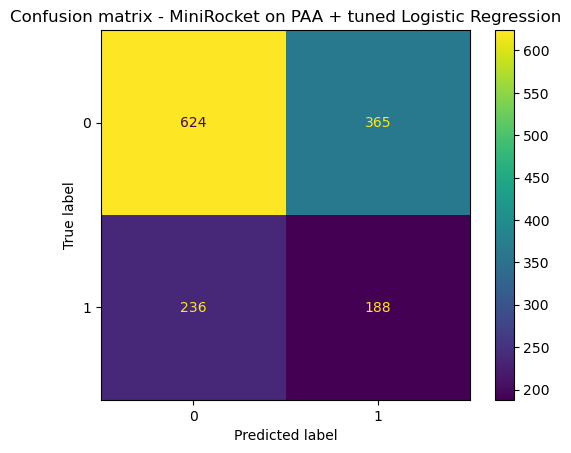

Exception ignored in: <function ResourceTracker.__del__ at 0x102f39bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105b35bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1083ddbc0>
Traceback (most recent call last

In [25]:
best_lr_paa = grid_search_paa.best_estimator_

paa_tuned_results = evaluate_classifier(
    best_lr_paa,
    X_train_mr_paa,
    y_train,
    X_test_mr_paa,
    y_test,
    model_name="MiniRocket on PAA + tuned Logistic Regression"
)

## New MINIROCKET

In [26]:
import os
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

random_state = 42
DATASET_DIR = "../dataset/"

In [27]:
try:
    from sktime.transformations.panel.rocket import MiniRocketMultivariate
    print("Imported MiniRocketMultivariate.")
except ImportError:
    try:
        from sktime.transformations.panel.rocket import MiniRocketMultivariateVariable as MiniRocketMultivariate
        print("Imported MiniRocketMultivariateVariable as MiniRocketMultivariate.")
    except ImportError as e:
        raise ImportError("Install/update sktime with: pip install -U sktime") from e

Imported MiniRocketMultivariate.


In [28]:
preprocessed_path = os.path.join(DATASET_DIR, "CMI_timeseries_preprocessed_outputs.pkl")
metadata_path = os.path.join(DATASET_DIR, "CMI_timeseries_metadata_filtered.pkl")

if not os.path.exists(preprocessed_path):
    raise FileNotFoundError(f"File not found: {preprocessed_path}")

if not os.path.exists(metadata_path):
    raise FileNotFoundError(f"File not found: {metadata_path}")

with open(preprocessed_path, "rb") as f:
    preprocessed_outputs = pickle.load(f)

metadata_df = pd.read_pickle(metadata_path)

print("Preprocessed output keys:")
print(preprocessed_outputs.keys())

print("\nMetadata shape:", metadata_df.shape)
print(metadata_df.columns.tolist())

print("\nTarget distribution:")
print(metadata_df["target"].value_counts().sort_index())

print("\nNumber of subjects:", metadata_df["subject_id"].nunique())

Preprocessed output keys:
dict_keys(['CMI_timeseries_preprocessed', 'CMI_timeseries_global_scaled', 'CMI_timeseries_subject_scaled', 'signal_cols', 'id_col', 'target_col', 'target_df', 'filtered_target_df', 'non_wear_df', 'hampel_summary_df'])

Metadata shape: (4310, 3)
['window_pos', 'subject_id', 'target']

Target distribution:
target
0    2888
1    1422
Name: count, dtype: int64

Number of subjects: 375


In [29]:
# IMPORTANT: Global scaled, full-resolution, no PAA

X_source = preprocessed_outputs["CMI_timeseries_global_scaled"]
signal_cols = preprocessed_outputs["signal_cols"]

print("Selected dataset: CMI_timeseries_global_scaled")
print("Number of windows:", len(X_source))
print("Signal columns:", signal_cols)

X_full_list = []

for ts_df in X_source:
    X_full_list.append(
        ts_df[signal_cols].to_numpy(dtype=float)
    )

X_ts = np.stack(X_full_list, axis=0)

y = metadata_df["target"].to_numpy()
groups = metadata_df["subject_id"].to_numpy()

print("X_ts shape:", X_ts.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

assert X_ts.shape[0] == len(y) == len(groups), "Mismatch between X, y, and groups."

Selected dataset: CMI_timeseries_global_scaled
Number of windows: 4310
Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez', 'light']
X_ts shape: (4310, 200, 6)
y shape: (4310,)
groups shape: (4310,)


In [30]:
# Same split logic as Classification2.0
# 4 folds gives approximately 25% test size.

splitter = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=random_state
)

train_idx, test_idx = next(splitter.split(X_ts, y, groups=groups))

X_train_raw = X_ts[train_idx]
X_test_raw = X_ts[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)

print("\nTrain target distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts().sort_index())

print("\nTrain subjects:", len(np.unique(groups_train)))
print("Test subjects:", len(np.unique(groups_test)))

overlap_subjects = set(groups_train).intersection(set(groups_test))
print("\nSubject overlap:", len(overlap_subjects))

assert len(overlap_subjects) == 0, "DATA LEAKAGE: subject appears in both train and test."

# Check same support as Classification2.0
expected_test_support = {0: 736, 1: 354}
actual_test_support = pd.Series(y_test).value_counts().sort_index().to_dict()

print("\nActual test support:", actual_test_support)

assert actual_test_support == expected_test_support, (
    f"Support mismatch. Expected {expected_test_support}, got {actual_test_support}. "
    "You are not reproducing the same split as Classification2.0."
)

print("\nSame support as Classification2.0 confirmed.")

Train shape: (3220, 200, 6)
Test shape: (1090, 200, 6)

Train target distribution:
0    2152
1    1068
Name: count, dtype: int64

Test target distribution:
0    736
1    354
Name: count, dtype: int64

Train subjects: 281
Test subjects: 94

Subject overlap: 0

Actual test support: {0: 736, 1: 354}

Same support as Classification2.0 confirmed.


In [31]:
def impute_non_finite_3d_train_only(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    n_channels = X_train.shape[2]
    channel_medians = []

    for j in range(n_channels):
        train_channel = X_train[:, :, j]
        finite_values = train_channel[np.isfinite(train_channel)]

        if len(finite_values) == 0:
            median_value = 0.0
        else:
            median_value = np.median(finite_values)

        channel_medians.append(median_value)

        X_train[:, :, j] = np.where(
            np.isfinite(X_train[:, :, j]),
            X_train[:, :, j],
            median_value
        )

        X_test[:, :, j] = np.where(
            np.isfinite(X_test[:, :, j]),
            X_test[:, :, j],
            median_value
        )

    return X_train, X_test, np.array(channel_medians)


X_train_full, X_test_full, train_channel_medians = impute_non_finite_3d_train_only(
    X_train_raw,
    X_test_raw
)

assert np.isfinite(X_train_full).all()
assert np.isfinite(X_test_full).all()

# MiniRocketMultivariate expects: n_instances x n_channels x n_timepoints
X_train_minirocket = np.transpose(X_train_full, (0, 2, 1)).astype(np.float32)
X_test_minirocket = np.transpose(X_test_full, (0, 2, 1)).astype(np.float32)

print("MiniRocket train shape:", X_train_minirocket.shape)
print("MiniRocket test shape:", X_test_minirocket.shape)

MiniRocket train shape: (3220, 6, 200)
MiniRocket test shape: (1090, 6, 200)


In [32]:
minirocket = MiniRocketMultivariate(
    num_kernels=10000,
    random_state=random_state
)

print("Fitting MiniRocket on training set only...")
minirocket.fit(X_train_minirocket, y_train)

print("Transforming train...")
X_train_mr = minirocket.transform(X_train_minirocket)

print("Transforming test...")
X_test_mr = minirocket.transform(X_test_minirocket)

X_train_mr = np.asarray(X_train_mr)
X_test_mr = np.asarray(X_test_mr)

print("X_train_mr shape:", X_train_mr.shape)
print("X_test_mr shape:", X_test_mr.shape)

Fitting MiniRocket on training set only...
Transforming train...
Transforming test...
X_train_mr shape: (3220, 9996)
X_test_mr shape: (1090, 9996)


In [33]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        solver="saga",
        max_iter=5000,
        random_state=random_state,
        n_jobs=-1
    ))
])

param_grid = {
    "logreg__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(
    X_train_mr,
    y_train,
    groups=groups_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV balanced accuracy:")
print(grid_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END ....................................logreg__C=0.001; total time= 1.3min
[CV] END ....................................logreg__C=0.001; total time= 1.4min
[CV] END ....................................logreg__C=0.001; total time= 1.5min
[CV] END ....................................logreg__C=0.001; total time= 1.6min
[CV] END ....................................logreg__C=0.001; total time= 1.9min
[CV] END .....................................logreg__C=0.01; total time= 5.9min
[CV] END .....................................logreg__C=0.01; total time= 6.9min
[CV] END .....................................logreg__C=0.01; total time= 7.0min
[CV] END .....................................logreg__C=0.01; total time= 5.8min
[CV] END .....................................logreg__C=0.01; total time= 6.8min
[CV] END ......................................logreg__C=0.1; total time=13.6min
[CV] END ......................................lo

Exception ignored in: <function ResourceTracker.__del__ at 0x1027b1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END .....................................logreg__C=10.0; total time=13.2min
[CV] END .....................................logreg__C=10.0; total time= 9.1min


Exception ignored in: <function ResourceTracker.__del__ at 0x10293dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


[CV] END ......................................logreg__C=1.0; total time=14.5min
[CV] END .....................................logreg__C=10.0; total time=14.2min
[CV] END .....................................logreg__C=10.0; total time=12.7min
[CV] END .....................................logreg__C=10.0; total time=10.9min


Exception ignored in: <function ResourceTracker.__del__ at 0x104f69bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1066b5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Best parameters:
{'logreg__C': 0.001}

Best CV balanced accuracy:
0.5679326546299895


MiniRocket Global Scaled + Logistic Regression

Train metrics:
Accuracy: 0.8937888198757764
Balanced accuracy: 0.9000224510254375
F1 macro: 0.8844369559961316

Test metrics:
Accuracy: 0.5825688073394495
Balanced accuracy: 0.547945836403832
F1 macro: 0.5440005663789719
Precision macro: 0.5444319560090913
Recall macro: 0.547945836403832

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       736
           1       0.38      0.45      0.41       354

    accuracy                           0.58      1090
   macro avg       0.54      0.55      0.54      1090
weighted avg       0.60      0.58      0.59      1090


Test support check:
0    736
1    354
Name: count, dtype: int64


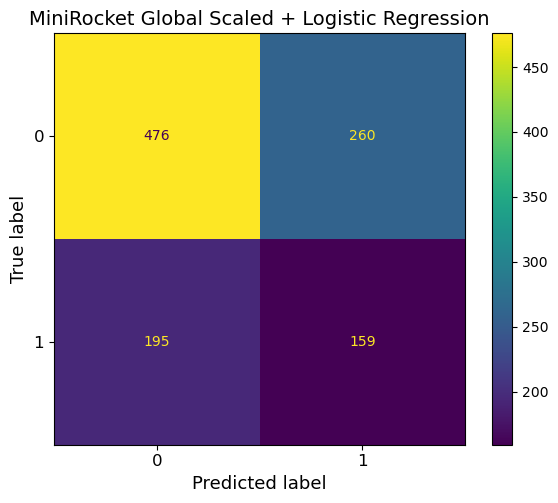

In [35]:
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train_mr)
y_test_pred = best_model.predict(X_test_mr)

print("=" * 80)
print("MiniRocket Global Scaled + Logistic Regression")
print("=" * 80)

print("\nTrain metrics:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_train, y_train_pred))
print("F1 macro:", f1_score(y_train, y_train_pred, average="macro", zero_division=0))

print("\nTest metrics:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("F1 macro:", f1_score(y_test, y_test_pred, average="macro", zero_division=0))
print("Precision macro:", precision_score(y_test, y_test_pred, average="macro", zero_division=0))
print("Recall macro:", recall_score(y_test, y_test_pred, average="macro", zero_division=0))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("\nTest support check:")
print(pd.Series(y_test).value_counts().sort_index())

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.unique(y_test)
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    cmap="viridis",
    values_format="d",
    colorbar=True
)

ax.set_title("MiniRocket Global Scaled + Logistic Regression", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=13)
ax.set_ylabel("True label", fontsize=13)

ax.tick_params(axis="both", labelsize=12)

plt.grid(False)
plt.tight_layout()
plt.show()